In [1]:
from pychiver.archiver import Archiver

### Import the data

In [54]:
archiver = Archiver(archiver_url='http://archiver-01.tn.esss.lu.se')

pvs = ("RFQ-010:RFS-VacMon-110:Status-Ilck-RB",
       "RFQ-010:RFS-VacMon-140:Status-Ilck-RB",
       "RFQ-010:RFS-FIM-101:RP1-Ilck-RB",  # reflected power 1
       "RFQ-010:RFS-FIM-101:RP2-Ilck-RB")  # reflected power 2

start = "2021-07-14 14:00:00"
end = "2021-07-14 15:30:00"

In [55]:
pvs_subset = (pvs[1],pvs[3])

In [56]:
from pychiver.calculations import LastAcquiredValueInterpolationStrategy

data = archiver.get(pvs_subset, start_date=start, end_date=end)

# data = archiver.getAligned((pvs[0],pvs[3]), start_date=start, end_date=end, 
#                            strategy=LastAcquiredValueInterpolationStrategy)

### Investigate the data

In [57]:
data[pvs[3]]

,secs,val,nanos,severity,status,status_label,severity_label,secs_nanos,time
0,1626271203,0,976285038,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626271e+09,2021-07-14 14:00:03.976284981
1,1626271204,1,70790996,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626271e+09,2021-07-14 14:00:04.070791006
2,1626271211,0,148172601,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626271e+09,2021-07-14 14:00:11.148172617
3,1626271211,1,233532787,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626271e+09,2021-07-14 14:00:11.233532906
4,1626271211,0,322027153,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626271e+09,2021-07-14 14:00:11.322027206
...,...,...,...,...,...,...,...,...,...
665,1626276441,1,711938788,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626276e+09,2021-07-14 15:27:21.711938858
666,1626276442,0,703005255,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626276e+09,2021-07-14 15:27:22.703005314
667,1626276443,1,711986494,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626276e+09,2021-07-14 15:27:23.711986542
668,1626276578,0,144469020,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.626277e+09,2021-07-14 15:29:38.144469023


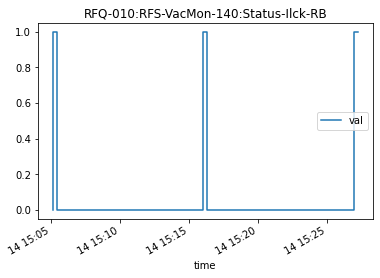

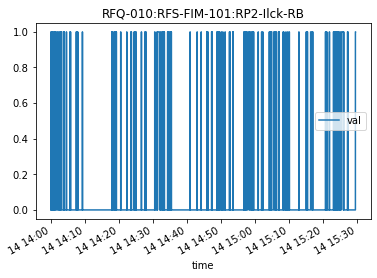

In [59]:
for one in pvs_subset:
    data[one].plot(x='time', y='val', title=one, drawstyle="steps")

## Finding close occurances

to find the similar occurances (default RISE), call `compare` method. It will return the timestamops of close (via the provided tolerance) occurances

In [61]:
from pychiver.calculations import Edge

comp_data = archiver.compare(pvs_subset,
                        start_date=start,
                        end_date=end,
                        #verbose=True,
                        tolerance_in_seconds=0.15,
                        compare_edge=Edge.FALLING
                            )


import datetime
for one in comp_data:
    print(datetime.datetime.fromtimestamp(one))

2021-07-14 17:27:19.708025
